In [1]:
# import everything first:
import numpy as np
import astropy.constants as const
import astropy.units as u
from matplotlib import pyplot as plt

In [2]:
# Constants
G = 6.674e-8        # cm^3 g^-1 s^-2
sigmaB = 5.67e-5    # erg cm^-2 s^-1 K^-4
kB = 1.381e-16      # erg/K
L_sun = 3.828e33    # erg/s
R_p = 7.149e9       # Jupiter radius in cm
AU = 1.496e13       # cm
L_jup = 3.846e30  # erg/s

# Physical constants
M_sun = 1.989e33 
M_jup = 1.898e30
R_jup = 7.149e9
#AU = 1.496e13
sec_per_yr = 3.156e7
Rgas = 8.314e7  # erg/(mol K)


Rp vs Mp Data:
  Mp range: 0.0160 to 10.3211 M_Jup
  Rp range: 0.6952 to 2.3048 R_Jup


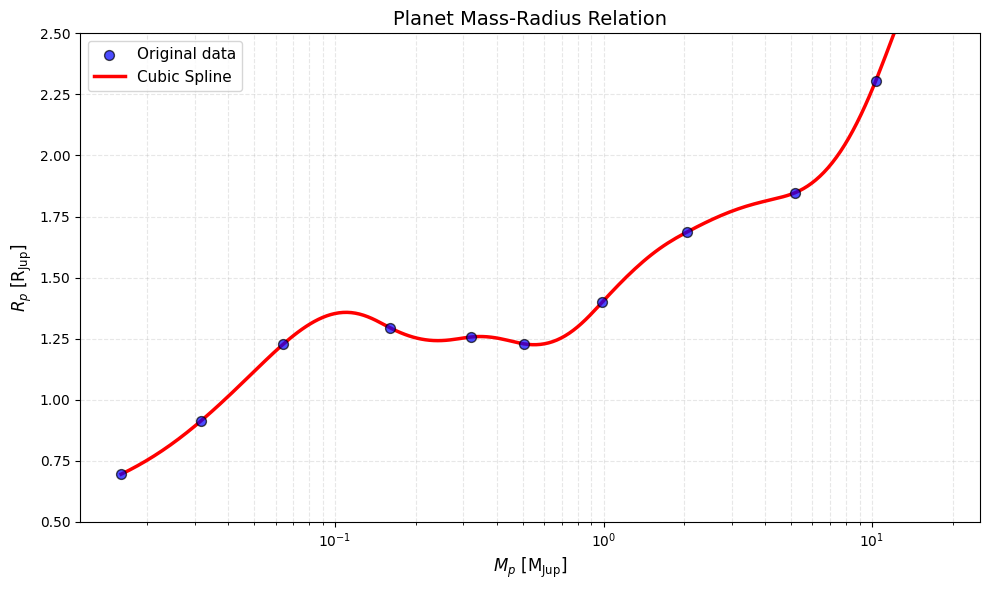

✅ Rp_from_Mp function created!
   Example: Rp_from_Mp(1.0) = 1.405 R_Jup
   Example: Rp_from_Mp(5.0) = 1.841 R_Jup

Lp vs Mp Data:
  Mp range: 0.0158 to 9.8432 M_Jup
  Lp range: 4.88e-09 to 1.64e-03 L_sun


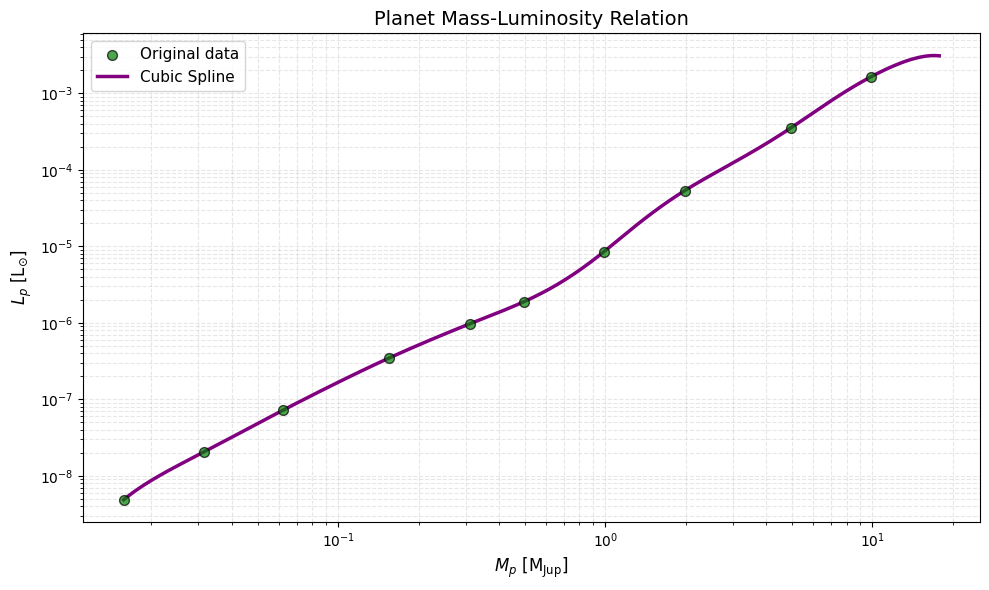

✅ Lp_from_Mp function created!
   Example: Lp_from_Mp(1.0) = 8.79e-06 L_sun
   Example: Lp_from_Mp(5.0) = 3.61e-04 L_sun


In [3]:
# Load CSV files
import pandas as pd
from scipy.interpolate import CubicSpline
import os

# Load Rp vs Mp data
csv_path_RpMp = os.path.join('..', 'RpMpAndrewstrial1.csv')
RpMp_data = pd.read_csv(csv_path_RpMp, header=None, skipinitialspace=True)

# Load Lp vs Mp data
csv_path_LpMp = os.path.join('..', 'LpMpAndrews.csv')
LpMp_data = pd.read_csv(csv_path_LpMp, header=None, skipinitialspace=True)

# ============================================
# 1. Rp vs Mp Interpolation
# ============================================

# Extract and sort Rp-Mp data
Mp_RpData = RpMp_data[0].values  # Planet mass [M_Jup]
Rp_data = RpMp_data[1].values    # Planet radius [R_Jup]

sort_idx_Rp = np.argsort(Mp_RpData)
Mp_RpData_sorted = Mp_RpData[sort_idx_Rp]
Rp_data_sorted = Rp_data[sort_idx_Rp]

print("=" * 50)
print("Rp vs Mp Data:")
print(f"  Mp range: {Mp_RpData_sorted.min():.4f} to {Mp_RpData_sorted.max():.4f} M_Jup")
print(f"  Rp range: {Rp_data_sorted.min():.4f} to {Rp_data_sorted.max():.4f} R_Jup")
print("=" * 50)

# Create interpolation grid
Mp_grid_Rp = np.logspace(np.log10(Mp_RpData_sorted.min()), 
                          1.25, 200)

# Cubic spline interpolation
Rp_spline = CubicSpline(Mp_RpData_sorted, Rp_data_sorted, bc_type='natural')
Rp_interpolated = Rp_spline(Mp_grid_Rp)

# Plot Rp vs Mp
plt.figure(figsize=(10, 6))
plt.scatter(Mp_RpData, Rp_data, label='Original data', color='blue', 
            s=50, alpha=0.7, edgecolors='black', zorder=3)
plt.plot(Mp_grid_Rp, Rp_interpolated, label='Cubic Spline', 
         linestyle='-', linewidth=2.5, color='red')
plt.xlabel(r'$M_p$ [M$_{\rm Jup}$]', fontsize=12)
plt.ylabel(r'$R_p$ [R$_{\rm Jup}$]', fontsize=12)
plt.title('Planet Mass-Radius Relation', fontsize=14)
plt.xscale('log')
plt.ylim(0.5, 2.5)  # Limit y-axis range
plt.legend(fontsize=11)
plt.grid(alpha=0.3, which='both', linestyle='--')
plt.tight_layout()
plt.show()

# Create reusable function
Rp_from_Mp = CubicSpline(Mp_RpData_sorted, Rp_data_sorted, 
                         bc_type='natural', extrapolate=True)

print(f"✅ Rp_from_Mp function created!")
print(f"   Example: Rp_from_Mp(1.0) = {Rp_from_Mp(1.0):.3f} R_Jup")
print(f"   Example: Rp_from_Mp(5.0) = {Rp_from_Mp(5.0):.3f} R_Jup\n")

# ============================================
# 2. Lp vs Mp Interpolation
# ============================================

# Extract and sort Lp-Mp data
Mp_LpData = LpMp_data[0].values  # Planet mass [M_Jup]
Lp_data = LpMp_data[1].values    # Planet luminosity [L_sun]

sort_idx_Lp = np.argsort(Mp_LpData)
Mp_LpData_sorted = Mp_LpData[sort_idx_Lp]
Lp_data_sorted = Lp_data[sort_idx_Lp]

print("=" * 50)
print("Lp vs Mp Data:")
print(f"  Mp range: {Mp_LpData_sorted.min():.4f} to {Mp_LpData_sorted.max():.4f} M_Jup")
print(f"  Lp range: {Lp_data_sorted.min():.2e} to {Lp_data_sorted.max():.2e} L_sun")
print("=" * 50)

# Create interpolation grid
Mp_grid_Lp = np.logspace(np.log10(Mp_LpData_sorted.min()), 
                          1.25, 200)

# Cubic spline interpolation
Lp_spline = CubicSpline(Mp_LpData_sorted, Lp_data_sorted, bc_type='natural')
Lp_interpolated = Lp_spline(Mp_grid_Lp)

# Plot Lp vs Mp
plt.figure(figsize=(10, 6))
plt.scatter(Mp_LpData, Lp_data, label='Original data', color='green', 
            s=50, alpha=0.7, edgecolors='black', zorder=3)
plt.plot(Mp_grid_Lp, Lp_interpolated, label='Cubic Spline', 
         linestyle='-', linewidth=2.5, color='purple')
plt.xlabel(r'$M_p$ [M$_{\rm Jup}$]', fontsize=12)
plt.ylabel(r'$L_p$ [L$_{\odot}$]', fontsize=12)
plt.title('Planet Mass-Luminosity Relation', fontsize=14)
plt.xscale('log')
plt.yscale('log')
plt.legend(fontsize=11)
plt.grid(alpha=0.3, which='both', linestyle='--')
plt.tight_layout()
plt.show()

# Create reusable function
Lp_from_Mp = CubicSpline(Mp_LpData_sorted, Lp_data_sorted, 
                         bc_type='natural', extrapolate=True)

print(f"✅ Lp_from_Mp function created!")
print(f"   Example: Lp_from_Mp(1.0) = {Lp_from_Mp(1.0):.2e} L_sun")
print(f"   Example: Lp_from_Mp(5.0) = {Lp_from_Mp(5.0):.2e} L_sun")
print("=" * 50)

In [ ]:
def B_nu(nu, T):
    """
    Planck function in frequency (erg s^-1 cm^-2 Hz^-1 sr^-1)
    nu: frequency in Hz
    T: temperature in K
    """
    h = 6.626e-27  # erg*s
    c = 2.998e10   # cm/s
    k = 1.381e-16  # erg/K
    
    return (2*h*nu**3 / c**2) / (np.exp(h*nu/(k*T)) - 1)

def calculate_disk_properties_Andrews(M_star = 1, Mp = 1, Mdot = 1.56, alpha = 1e-3, kappaR = 10 , Rin = 1, rp = 22, d_pc = 167, 
                             lam_nu=240 ,lam_mm=1.3, kappa_nu =None,
                             Lstar = 1.0 , show_results = False, Rout=None, M_cpd = 0.01, i = 16):
    """
    Calculate disk temperature profiles and millimeter flux.
    
    Parameters:
    -----------
    M_star : float
        Stellar mass (M_sun)
    lam_nu : float
        Frequency (GHz)
    Mp : float
        Planet mass (M_jup)
    Mdot : float  
        Accretion rate (M_jup/Myr)
    alpha : float
        Viscosity parameter
    kappaR : float
        Rosseland opacity (cm^2/g)
    Rin : float
        Inner radius (Rjup)
    Rp : float
        distance of planet from star (au)  
    d_pc : float
        Distance (pc)
    mode : str
        Irradiation mode: "b", "no_b", or "planet'
    T_ISM : float
        Interstellar medium temperature (K)
    Lplanet : float
        Planet luminosity (L_sun)
    

    Lstar : float
        Stellar luminosity (L_sun)
        
    Returns:
    --------
    dict : Dictionary containing R, temperatures, Sigma, tau_mm, Tb, F_nu_tot
    """
    # Turn input values to cgs
    # Disk parameters
    M_star = M_star * M_sun
    Mp = Mp * M_jup
    Mdot = Mdot * M_jup / (sec_per_yr*1e6)
    Rin = Rin * R_jup
    rp = rp * AU # planet orbital radius in cm
    Rp = Rp_from_Mp(Mp / M_jup)*R_jup  # planet radius in cm

    # Turn the luminosites to erg/s
    Lstar = Lstar * L_sun
    
    # 1. Create radial grid between Rin and Rout

    

    if Rout is None:
        Rout = (1/3) * rp * (Mp / (3 * M_star))**(1/3)
    else:
        Rout = Rout * AU  # assume input Rout is in AU


    R = np.geomspace(Rp*1.01, Rout, 100)  # cm
    
    # 2. Calculate T(R)
    # Accretion irradiation
    
    T_irr = (3*G * Mp * Mdot / (8*np.pi*sigmaB*R**3) * (1 - np.sqrt(Rp/R)))**(1/4)  # K # RJUP CAN BE WRONG  NEED PLANET RADIUS
    
    #print(f'L_irr = {L_irr/L_sun:.2e} L_sun')

    # Planet irradiation
    Lplanet = Lp_from_Mp(Mp / M_jup) * L_sun  # erg/s
    T_irr_p = (0.1 * Lplanet  / (4 * np.pi * sigmaB * R**2))**0.25  # K  , R is coordinate in CPD frame

    # Star irradiation

    phi_flare = 0.02   # flaring angle of the host disk   (Huang et al. (2018b))

    T_irr_star = (phi_flare * Lstar / (8 * np.pi * sigmaB * rp**2))**0.25  # K

    T_ext= (T_irr**4 + T_irr_p**4 + T_irr_star**4 )**0.25  # K
    
    
    #---------------------------------------
    # -------------SIGMA--------------------
    # --------------------------------------
    
    gamma = 0.75
    M_cpd = M_cpd * M_jup  # CPD mass in grams


    Sigma0 = (2 - gamma) * M_cpd /  (2 * np.pi * Rout**gamma) * (Rout**(2 - gamma) - Rp**(2 - gamma))**(-1)
    Sigma = Sigma0 * (R/Rout)**(-gamma)




    #---------------------------------------
    #---------------Flux--------------------
    # --------------------------------------
      
 

    kappa_nu = 2.4 #cm^2/g at 0.9mm 

    #if kappa_nu is not None:
    #    kappa_nu = kappa_nu
    #else :
    #    kappa_mm = 0.034*(0.87/lam_mm)
    #    kappa_nu = kappa_mm

    tau_nu = kappa_nu * Sigma

    # Assume face-on disk: mu = cos(i) = 1

    # turn i from degree to radian
   
    mu = np.cos(np.radians(i))# i is the inclination angle in degree in table 2 

    # Convert distance to cm
    pc_to_cm = 3.086e18  # cm/pc
    d_cm = d_pc * pc_to_cm

    # Integrand: B_nu(T) * (1 - exp(-tau/mu)) * r
    # Ignoring omega_nu (scattering) term as specified
    integrand = B_nu(lam_nu * 1e9, T_ext) * (1 - np.exp(-tau_nu / mu)) * R

    # Integrate using trapezoidal rule
    flux_integral = np.trapz(integrand, R)

    # Total observed flux at Earth
    F_cpd = (2 * np.pi * mu / d_cm**2) * flux_integral  # erg s^-1 cm^-2 Hz^-1

    # Convert to microJy
    F_microJy = F_cpd / 1e-29  # µJy

    
    return {
        'R': R,
        'Rout': Rout / AU,
        'R_AU': R / AU,
        'T_ext': T_ext,
        'Sigma': Sigma,
        'tau_nu_max': np.max(tau_nu),
        'F_nu_tot': F_microJy,
        'M_cpd': M_cpd / M_jup,
        'T_irr': T_irr,
        'T_irr_p': T_irr_p,
        'T_irr_star': T_irr_star
    }




### Check model consistency with Andrews HD143006

Measure the flux limit at the innergap of the disk and try to obtain the same planet properties. Relevant to table 3 and table 4  - try to reproduce table 4.
since the observation is made in different wavelengths, I will take the flux he measured at the wavelength and the location of the gap, plug into my model to plot the radius versus planet mass for D22 and D51 gap. 

1. Change the gap location unit from mas to au (au = mas *dc/1000)
2. Makesure flux is in value of microJy (take the range of flux values for each recovery fraction to verify as it would make it more convenient for me if I want to do CPD injection recovery too) 
3. Plot them


*Note: the observing frequency is 240 GHz which is 1.25 mm , the wavelength-dependent opacity is 2.4 cm^2/g*


Okay , so the situation now is that , the contour levels should be changed into recovery fractions (if present) or sigma levels , the one overlaying line should be the ALMA angular resolution,  representing the locus of CPD parameters where the CPD angular size equals the beam: theta_cpd = Rcpd/d = theta_ALMA, therefore y axis (Rcpd/RHill) = theta_beam*d/RHill , where RHill depends on Mp. so thats the contour line that shows below which the CPD is unresolved. 
without the recovery fractions...what is the minimum flux? should I keep the whole recovery fraction relevant relation as an if case? 




In [40]:
def compute_flux_map(
    target_flux_arr,
    disk_arr,
    rp=165,
    alpha=1e-3,
    y_max=0.8,
    y_min=0.05,
    lam_nu=240,
    lam_mm=1.3,
    kappa_nu=None,
    i=16,
    mode="default",
    overwrite=False,
    save=True,
    verbose=True
):
    """
    Compute flux and CPD mass grids for given disk parameters.
    Optionally caches results in /Andrews folder.

    Returns:
        Mp_grid, Rout_frac_grid, Flux_vals, M_cpd_chosen
    """
    import os
    import numpy as np
    import pandas as pd

    # === Optional caching ===
    save_dir = "Andrews"
    os.makedirs(save_dir, exist_ok=True)
    fname = f"{disk_arr[0]}_{rp}_alpha{alpha}_{mode}.csv"
    save_path = os.path.join(save_dir, fname)

    if save and os.path.exists(save_path) and not overwrite:
        if verbose:
            print(f"Loading cached results from {save_path}")
        df = pd.read_csv(save_path)
        Mp_grid = df['Mp_grid'].unique()
        Rout_frac_grid = df['Rout_frac_grid'].unique()
        Flux_vals = df['Flux_vals'].values.reshape(len(Rout_frac_grid), len(Mp_grid))
        M_cpd_chosen = df['Mcpd_vals'].values.reshape(len(Rout_frac_grid), len(Mp_grid))
        return Mp_grid, Rout_frac_grid, Flux_vals, M_cpd_chosen

    # === Computation ===
    Mp_grid = np.logspace(-2, 1.25, 100)
    M_cpd_grid = np.logspace(-5.5, -3, 80)
    Rout_frac_grid = np.linspace(y_min, y_max, 80)
    M_star_jup = disk_arr[1] * 1047.56

    Flux_vals = np.zeros((len(Rout_frac_grid), len(Mp_grid)))
    M_cpd_chosen = np.zeros_like(Flux_vals)

    for i, frac in enumerate(Rout_frac_grid):
        for j, Mp in enumerate(Mp_grid):
            RHill = rp * (Mp / (3 * M_star_jup))**(1 / 3)
            Rout = frac * RHill

            Rp_planet = Rp_from_Mp(Mp)
            Rp_planet_AU = Rp_planet * R_jup / AU
            if Rout <= Rp_planet_AU:
                continue

            for M_cpd in M_cpd_grid:
                out = calculate_disk_properties_Andrews(
                    M_star=disk_arr[1], Mp=Mp, alpha=alpha,
                    Rin=1, rp=rp, d_pc=disk_arr[2],
                     Lstar=disk_arr[3],
                    Rout=Rout, M_cpd=M_cpd, i=i, lam_mm=lam_mm, lam_nu=lam_nu
                )
                flux = out['F_nu_tot']
                if flux >= target_flux_arr[0]:
                    Flux_vals[i, j] = flux
                    M_cpd_chosen[i, j] = M_cpd
                    break

            if verbose and (i % 10 == 0 and j % 20 == 0):
                print(f"[{i:02d},{j:02d}] Rout/RH={frac:.3f}, Mp={Mp:.3f} -> Fν={Flux_vals[i,j]:.2f} µJy")

    if verbose:
        print(f"Non-zero flux points: {np.sum(Flux_vals > 0)}")
        print(f"Non-zero M_cpd points: {np.sum(M_cpd_chosen > 0)}")

    # === Save ===
    if save:
        df = pd.DataFrame({
            'Mp_grid': np.tile(Mp_grid, len(Rout_frac_grid)),
            'Rout_frac_grid': np.repeat(Rout_frac_grid, len(Mp_grid)),
            'Flux_vals': Flux_vals.flatten(),
            'Mcpd_vals': M_cpd_chosen.flatten()
        })
        df.to_csv(save_path, index=False)
        if verbose:
            print(f"Saved results to {save_path}")

    return Mp_grid, Rout_frac_grid, Flux_vals, M_cpd_chosen

def plot_flux_map(Mp_grid, Rout_frac_grid, Flux_vals, M_cpd_chosen,
                  disk_arr, rp=165, alpha=1e-3, res_au = 7.4 , plotmass=True,
                  color='Blues', y_max=0.8, y_min=0.05):
    """
    Plot precomputed flux or CPD-mass maps with flexible styling.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    fig, ax = plt.subplots(figsize=(7, 5))

    if plotmass:
        levels = np.arange(-5.5, -3.2, 0.2)
        cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),
                         levels=levels, cmap=color)
        cbar = plt.colorbar(cf, ax=ax)
        cbar.set_label(r'$\log_{10}(M_{\rm CPD}/M_{\rm Jup})$', fontsize=11)
    else:
        cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, Flux_vals,
                         levels=7, cmap=color)
        cbar = plt.colorbar(cf, ax=ax)
        cbar.set_label(r'$F_\nu\, [\mu{\rm Jy}]$', fontsize=11)

    # Add ALMA beam limit
    M_star_jup = disk_arr[1] * 1047.56
    RHill_arr = rp * (Mp_grid / (3 * M_star_jup))**(1/3)
    #Rout_frac_beam = 7.4/ (2 * RHill_arr) # Jane Huang 2018 table 2
    # res_au = theta_beam*d_pc 
    Rout_frac_beam = res_au/(2 * RHill_arr) # Updated beam limit calculation
    ax.plot(np.log10(Mp_grid), Rout_frac_beam, color='red', lw=2, label='detection limit')

    ax.set_xlabel(r"$\log_{10}(M_p/M_{Jup})$")
    ax.set_ylabel(r"$R_{\rm cpd}/R_H$")
    ax.set_ylim(y_min, y_max)
    ax.legend()

    ax.set_title(f"{disk_arr[0]} at $r_p$={rp:.1f} AU, α={alpha}")
    plt.tight_layout()
    plt.show()

In [ ]:
# Gap of HD143006 from Andrews paper
# D22:  103 (mas for r_peak), 
# D51  : 338 (mas for r_peak),

HD1423006_disk_arr = ["HD143006", 1.56, 167, 3.8]

D22_target_flux_arr = [71, 79, 88, 97, 111, 220]  # mu Jy for different recovery fractions from 0.5 to 1.0

D51_target_flux_arr = [85, 92, 98, 107, 120, 185]  # mu Jy for different recovery fractions from 0.5 to 1.0
rD22 = 22 #140 * HD1423006_disk_arr[2] / 1000  # arcsec to au
rD51 = 51 #315* HD1423006_disk_arr[2] / 1000  # arcsec to au

Mp_D22, Rout_D22, Flux_D22, Mcpd_D22 = compute_flux_map(
    target_flux_arr=D22_target_flux_arr,
    disk_arr=HD1423006_disk_arr,
    rp=rD22,
    alpha=1e-3,
    kappa_nu=2.4,
    lam_nu=240,
    overwrite=True
)

Mp_D51, Rout_D51, Flux_D51, Mcpd_D51 = compute_flux_map(
    target_flux_arr=D51_target_flux_arr,
    disk_arr=HD1423006_disk_arr,
    rp=rD51,
    alpha=1e-3,
    kappa_nu=2.4,
    lam_nu=240,
    overwrite=True
)

C:\Users\LHEM\AppData\Local\Temp\ipykernel_11752\1232234450.py:89: RuntimeWarning: invalid value encountered in power
  T_irr_p = (0.1 * Lplanet  / (4 * np.pi * sigmaB * R**2))**0.25  # K  , R is coordinate in CPD frame
C:\Users\LHEM\AppData\Local\Temp\ipykernel_11752\1232234450.py:145: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  flux_integral = np.trapz(integrand, R)


[00,00] Rout/RH=0.050, Mp=0.010 -> Fν=0.00 µJy
[00,20] Rout/RH=0.050, Mp=0.045 -> Fν=0.00 µJy
[00,40] Rout/RH=0.050, Mp=0.206 -> Fν=0.00 µJy
[00,60] Rout/RH=0.050, Mp=0.933 -> Fν=0.00 µJy
[00,80] Rout/RH=0.050, Mp=4.229 -> Fν=0.00 µJy
[10,00] Rout/RH=0.145, Mp=0.010 -> Fν=0.00 µJy
[10,20] Rout/RH=0.145, Mp=0.045 -> Fν=0.00 µJy
[10,40] Rout/RH=0.145, Mp=0.206 -> Fν=0.00 µJy
[10,60] Rout/RH=0.145, Mp=0.933 -> Fν=0.00 µJy
[10,80] Rout/RH=0.145, Mp=4.229 -> Fν=0.00 µJy
[20,00] Rout/RH=0.240, Mp=0.010 -> Fν=0.00 µJy
[20,20] Rout/RH=0.240, Mp=0.045 -> Fν=0.00 µJy
[20,40] Rout/RH=0.240, Mp=0.206 -> Fν=0.00 µJy
[20,60] Rout/RH=0.240, Mp=0.933 -> Fν=0.00 µJy
[20,80] Rout/RH=0.240, Mp=4.229 -> Fν=0.00 µJy
[30,00] Rout/RH=0.335, Mp=0.010 -> Fν=0.00 µJy
[30,20] Rout/RH=0.335, Mp=0.045 -> Fν=0.00 µJy
[30,40] Rout/RH=0.335, Mp=0.206 -> Fν=0.00 µJy
[30,60] Rout/RH=0.335, Mp=0.933 -> Fν=0.00 µJy
[30,80] Rout/RH=0.335, Mp=4.229 -> Fν=71.12 µJy
[40,00] Rout/RH=0.430, Mp=0.010 -> Fν=0.00 µJy
[40,20] Rout

C:\Users\LHEM\AppData\Local\Temp\ipykernel_11752\1575728975.py:110: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


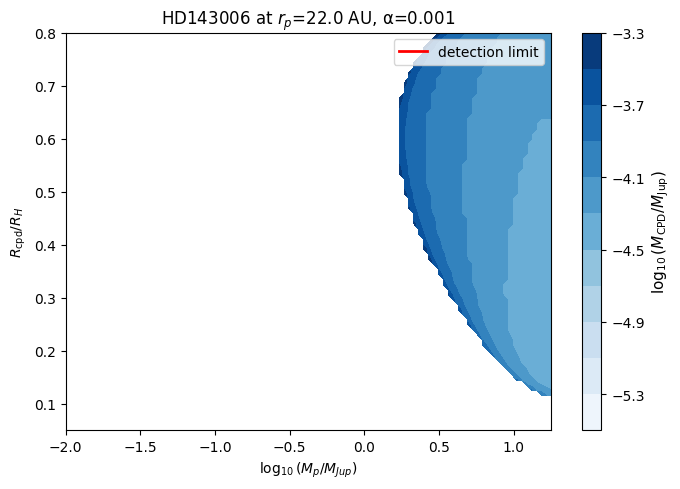

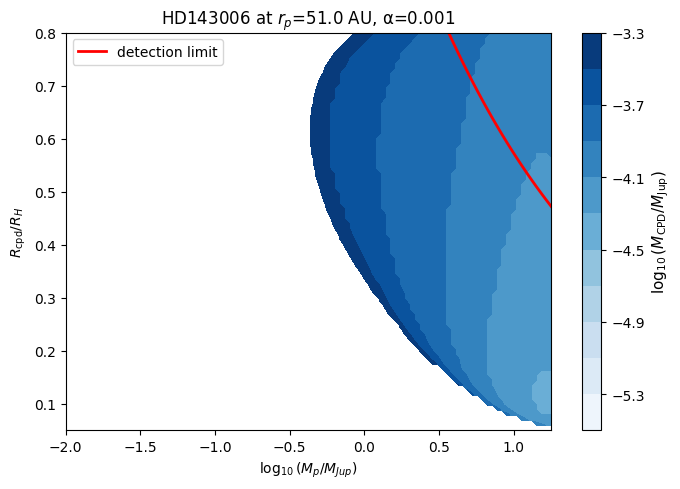

In [38]:
# D22 gap
plot_flux_map(
    Mp_D22, Rout_D22, Flux_D22, Mcpd_D22,
    disk_arr=HD1423006_disk_arr,
    rp=rD22,
    alpha=1e-3,
    plotmass=True,
    y_min=0.05,
    y_max=0.8,
    res_au=7.4

)

# D51 gap
plot_flux_map(
    Mp_D51, Rout_D51, Flux_D51, Mcpd_D51,
    disk_arr=HD1423006_disk_arr,
    rp=rD51,
    alpha=1e-3,
    plotmass=True,
    y_min=0.05,
    y_max=0.8,
    res_au=7.4
)

In [8]:
print(80*60*100)

480000


# Extend the method to exoALMA targets

In [ ]:
# Extend it to ALMA disks
 # name, Mstar (Msun), d_pc, Lstar (Lsun), Fnu (muJy), inc (deg)
disk_arr = {
    "AA_Tau":      ["AA_Tau", 0.79, 145, 1.1, 0.12, 58.54],
    "CQ_Tau":      ["CQ_Tau", 1.4, 149, 10, 0.135, 35.24],
    "DM_Tau":      ["DM_Tau", 0.45, 144, 0.24, 0.134, 35.97],
    "HD_34282":    ["HD_34282", 1.61, 309, 108, 0.106, 59.09],
    "HD_135344B":  ["HD_135344B", 1.61, 135, 6.7, 0.26, 20.73],
    "HD_143006":   ["HD_143006", 1.56, 167, 3.8, 0.226, 18.69],
    "J1604":       ["J1604", 1.29, 112, None, 0.257, 8.72],
    "J1615":       ["J1615", 1.14, 156, None, 0.303, 47.10],
    "J1842":       ["J1842", 1.07, 151, 0.8, 0.235, 39.22],
    "J1852":       ["J1852", 1.03, 147, 0.6, 0.236, 32.50],
    "LkCa_15":     ["LkCa_15", 1.14, 156, 1, 0.131, 50.59],
    "MWC_758":     ["MWC_758", 1.4, 151, 10.4, 0.241, 7.27],
    "PDS_66":      ["PDS_66", 1.28, 98, 1.2, 0.234, 32.02],
    "SY_Cha":      ["SY_Cha", 0.77, 182, None, 0.178, 51.65],
    "V4046_Sgr":   ["V4046_Sgr", 1.73, 72, 0.5, 0.241, 33.36],
}

In [20]:



five_sigma_sources = [
    # Format: [disk_name, radius_au, flux_ujy, sigma_flux_ujy, PB]
    ["CQ_Tau", 165.37, 260.30, 45.81 , 0.99],
    ["CQ_Tau", 932.14, 222.35, 40.25,0.76],
    ["DM_Tau", 1845.47, 5422.67, 161.82, 0.36],
    ["V4046_Sgr", 837.63, 90.54,22.22, 0.42],
]


# Planet kink 



In [28]:
for disk_name, radius_au, flux_ujy, sigma_flux_ujy, PB in five_sigma_sources:
    compute_flux_map(
        target_flux_arr=[sigma_flux_ujy*PB],
        disk_arr=disk_arr[disk_name],
        rp=radius_au,
        lam_nu=331.6,
        lam_mm=1.3e-1,
        alpha=1e-3,
        i = disk_arr[disk_name][5],
        mode ="5sigma",
        overwrite=True,
    )


# need change all the Andrew specific lie wavelength and detection limits


C:\Users\LHEM\AppData\Local\Temp\ipykernel_11752\1301021922.py:89: RuntimeWarning: invalid value encountered in power
  T_irr_p = (0.1 * Lplanet  / (4 * np.pi * sigmaB * R**2))**0.25  # K  , R is coordinate in CPD frame
C:\Users\LHEM\AppData\Local\Temp\ipykernel_11752\1301021922.py:145: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  flux_integral = np.trapz(integrand, R)


[00,00] Rout/RH=0.050, Mp=0.010 -> Fν=0.00 µJy
[00,20] Rout/RH=0.050, Mp=0.045 -> Fν=0.00 µJy
[00,40] Rout/RH=0.050, Mp=0.206 -> Fν=0.00 µJy
[00,60] Rout/RH=0.050, Mp=0.933 -> Fν=46.21 µJy
[00,80] Rout/RH=0.050, Mp=4.229 -> Fν=46.92 µJy
[10,00] Rout/RH=0.145, Mp=0.010 -> Fν=0.00 µJy
[10,20] Rout/RH=0.145, Mp=0.045 -> Fν=0.00 µJy
[10,40] Rout/RH=0.145, Mp=0.206 -> Fν=45.43 µJy
[10,60] Rout/RH=0.145, Mp=0.933 -> Fν=46.82 µJy
[10,80] Rout/RH=0.145, Mp=4.229 -> Fν=48.03 µJy
[20,00] Rout/RH=0.240, Mp=0.010 -> Fν=0.00 µJy
[20,20] Rout/RH=0.240, Mp=0.045 -> Fν=47.04 µJy
[20,40] Rout/RH=0.240, Mp=0.206 -> Fν=47.56 µJy
[20,60] Rout/RH=0.240, Mp=0.933 -> Fν=46.24 µJy
[20,80] Rout/RH=0.240, Mp=4.229 -> Fν=47.20 µJy
[30,00] Rout/RH=0.335, Mp=0.010 -> Fν=0.00 µJy
[30,20] Rout/RH=0.335, Mp=0.045 -> Fν=46.25 µJy
[30,40] Rout/RH=0.335, Mp=0.206 -> Fν=48.29 µJy
[30,60] Rout/RH=0.335, Mp=0.933 -> Fν=47.11 µJy
[30,80] Rout/RH=0.335, Mp=4.229 -> Fν=47.53 µJy
[40,00] Rout/RH=0.430, Mp=0.010 -> Fν=0.00 µJy


C:\Users\LHEM\AppData\Local\Temp\ipykernel_11752\1575728975.py:110: RuntimeWarning: divide by zero encountered in log10
  cf = ax.contourf(np.log10(Mp_grid), Rout_frac_grid, np.log10(M_cpd_chosen),


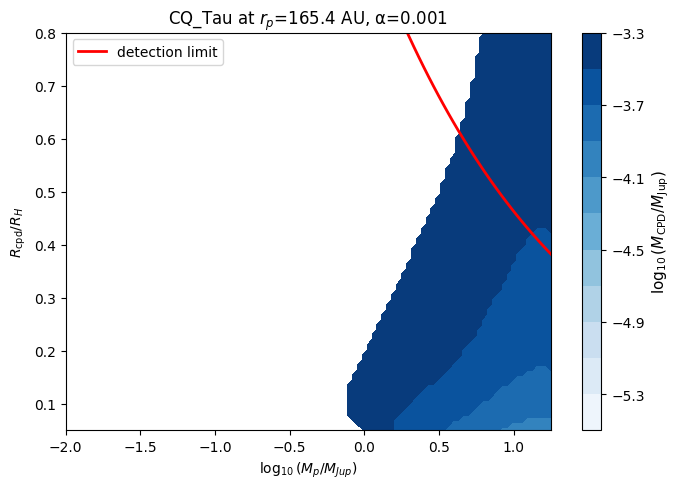

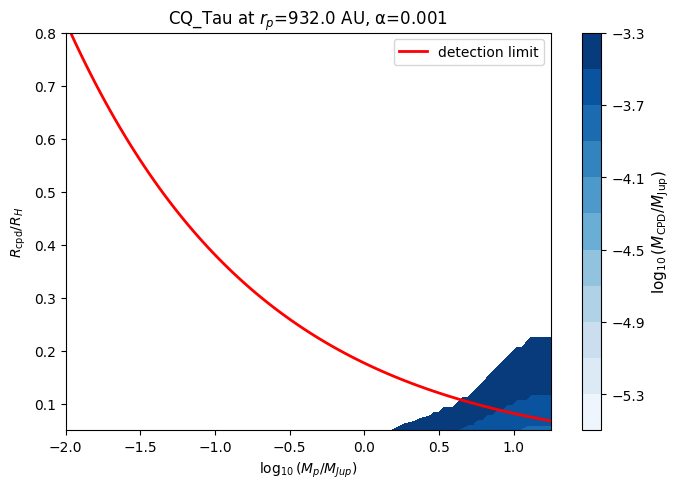

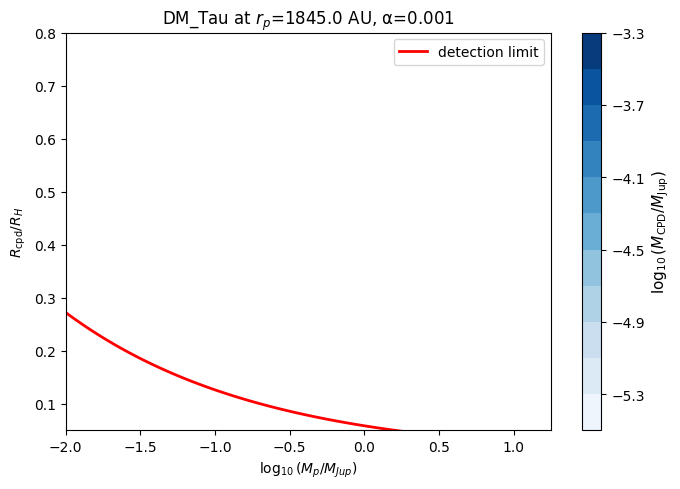

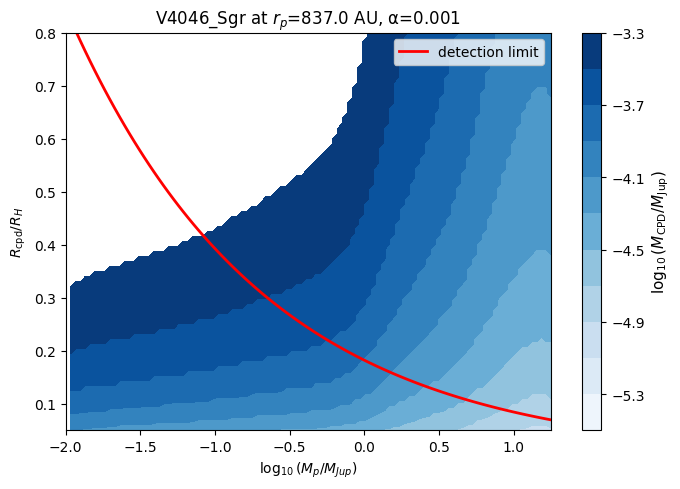

In [35]:
# plot all of the 5 sig source by loading the csv files

CQTau165 = pd.read_csv(os.path.join('Andrews', 'CQ_Tau_165.37_alpha0.001_5sigma.csv'))
CQTau932 = pd.read_csv(os.path.join('Andrews', 'CQ_Tau_932.14_alpha0.001_5sigma.csv'))
DMTau1845 = pd.read_csv(os.path.join('Andrews', 'DM_Tau_1845.47_alpha0.001_5sigma.csv'))
V4046Sgr837 = pd.read_csv(os.path.join('Andrews', 'V4046_Sgr_837.63_alpha0.001_5sigma.csv'))

plot_flux_map(
    CQTau165['Mp_grid'].unique(),
    CQTau165['Rout_frac_grid'].unique(),
    CQTau165.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals').values,
    CQTau165.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals').values,
    disk_arr=disk_arr['CQ_Tau'],
    rp=165.37,
    alpha=1e-3,
    plotmass=True,
    y_min=0.05,
    y_max=0.8,
    res_au=disk_arr['CQ_Tau'][4]*disk_arr['CQ_Tau'][2]
)

plot_flux_map(
    CQTau932['Mp_grid'].unique(),
    CQTau932['Rout_frac_grid'].unique(),
    CQTau932.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals').values,
    CQTau932.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals').values,
    disk_arr=disk_arr['CQ_Tau'],
    rp=932,
    alpha=1e-3,
    plotmass=True,
    y_min=0.05,
    y_max=0.8,
    res_au=disk_arr['CQ_Tau'][4]*disk_arr['CQ_Tau'][2]
)

plot_flux_map(
    DMTau1845['Mp_grid'].unique(),
    DMTau1845['Rout_frac_grid'].unique(),
    DMTau1845.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals').values,
    DMTau1845.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals').values,
    disk_arr=disk_arr['DM_Tau'],
    rp=1845,
    alpha=1e-3,
    plotmass=True,
    y_min=0.05,
    y_max=0.8,
    res_au=disk_arr['DM_Tau'][4]*disk_arr['DM_Tau'][2]
)


plot_flux_map(
    V4046Sgr837['Mp_grid'].unique(),
    V4046Sgr837['Rout_frac_grid'].unique(),
    V4046Sgr837.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals').values,
    V4046Sgr837.pivot(index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals').values,
    disk_arr=disk_arr['V4046_Sgr'],
    rp=837,
    alpha=1e-3,
    plotmass=True,
    y_min=0.05,
    y_max=0.8,
    res_au=disk_arr['V4046_Sgr'][4]*disk_arr['V4046_Sgr'][2]
)

